In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
%pip install scikit-learn
%pip install numpy
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Membuat data statis secara manual
# Data sudah berbentuk angka agar bisa langsung diproses oleh Random Forest

# Keterangan:
# gender           : 1 = Male, 0 = Female
# partner          : 1 = Yes, 0 = No
# internet_service : 3 = Fiber optic, 2 = DSL, 1 = No
# online_security  : 1 = Yes, 0 = No
# monthly_charge   : biaya bulanan pelanggan
# tenure           : lama pelanggan berlangganan dalam bulan
# churn            : 1 = Churn, 0 = Tidak Churn

data = pd.DataFrame({
    'gender': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
               1, 0, 1, 0, 1, 0, 1, 0, 1, 0],

    'partner': [1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
                1, 0, 1, 0, 0, 1, 1, 0, 1, 0],

    'internet_service': [3, 2, 1, 3, 2, 1, 3, 2, 1, 2,
                         3, 1, 3, 2, 3, 1, 3, 2, 1, 3],

    'online_security': [0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
                        0, 0, 0, 1, 0, 0, 0, 1, 0, 0],

    'monthly_charge': [90, 55, 25, 95, 60, 20, 100, 58, 22, 65,
                       98, 24, 92, 57, 105, 21, 97, 59, 23, 99],

    'tenure': [5, 24, 36, 3, 30, 40, 4, 28, 45, 22,
               6, 38, 7, 27, 2, 42, 5, 29, 44, 3],

    'churn': [1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
              1, 0, 1, 0, 1, 0, 1, 0, 0, 1]
})

# Menampilkan data
data

,gender,partner,internet_service,online_security,monthly_charge,tenure,churn
0,1,1,3,0,90,5,1
1,0,0,2,1,55,24,0
2,1,0,1,0,25,36,0
3,0,1,3,0,95,3,1
4,1,1,2,1,60,30,0
5,0,0,1,0,20,40,0
6,1,1,3,0,100,4,1
7,0,0,2,1,58,28,0
8,1,0,1,0,22,45,0
9,0,1,2,1,65,22,0


In [4]:
# Menampilkan jumlah data pada setiap kolom
data.count()

gender              20
partner             20
internet_service    20
online_security     20
monthly_charge      20
tenure              20
churn               20
dtype: int64

In [5]:
# Menampilkan 5 data pertama
data.head()

,gender,partner,internet_service,online_security,monthly_charge,tenure,churn
0,1,1,3,0,90,5,1
1,0,0,2,1,55,24,0
2,1,0,1,0,25,36,0
3,0,1,3,0,95,3,1
4,1,1,2,1,60,30,0


In [6]:
# Menampilkan informasi dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            20 non-null     int64
 1   partner           20 non-null     int64
 2   internet_service  20 non-null     int64
 3   online_security   20 non-null     int64
 4   monthly_charge    20 non-null     int64
 5   tenure            20 non-null     int64
 6   churn             20 non-null     int64
dtypes: int64(7)
memory usage: 1.2 KB


In [7]:
# Menampilkan statistik dasar dataset
data.describe()

,gender,partner,internet_service,online_security,monthly_charge,tenure,churn
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.500000,0.500000,2.100000,0.300000,63.250000,22.000000,0.400000
std,0.512989,0.512989,0.852242,0.470162,31.966883,16.013152,0.502625
min,0.000000,0.000000,1.000000,0.000000,20.000000,2.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,24.750000,5.000000,0.000000
50%,0.500000,0.500000,2.000000,0.000000,59.500000,25.500000,0.000000
75%,1.000000,1.000000,3.000000,1.000000,95.500000,36.500000,1.000000
max,1.000000,1.000000,3.000000,1.000000,105.000000,45.000000,1.000000


In [8]:
# X adalah fitur atau variabel input
# Fitur digunakan oleh model untuk melakukan prediksi

X = data.drop('churn', axis=1)

# y adalah target atau label yang ingin diprediksi

y = data['churn']

# Menampilkan ukuran X dan y
print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (20, 6)
Ukuran y: (20,)


In [9]:
# Membagi data menjadi data training dan data testing
# 70% data digunakan untuk training
# 30% data digunakan untuk testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Menampilkan jumlah data training dan testing
print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 14
Jumlah data testing: 6


In [10]:
# Membuat model Random Forest Classifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [11]:
# Melatih model menggunakan data training

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# Melakukan prediksi menggunakan data testing

y_pred = model_rf.predict(X_test)

# Menampilkan hasil prediksi
y_pred

array([1, 0, 0, 0, 0, 0])

In [13]:
# Membuat tabel perbandingan antara data aktual dan hasil prediksi

hasil = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

hasil

,Aktual,Prediksi
0,1,1
17,0,0
15,0,0
1,0,0
8,0,0
5,0,0


In [14]:
# Menghitung akurasi model

akurasi = accuracy_score(y_test, y_pred)

print("Akurasi Random Forest:", akurasi)

Akurasi Random Forest: 1.0


In [15]:
# Membuat confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Menampilkan confusion matrix
cm

array([[5, 0],
       [0, 1]])

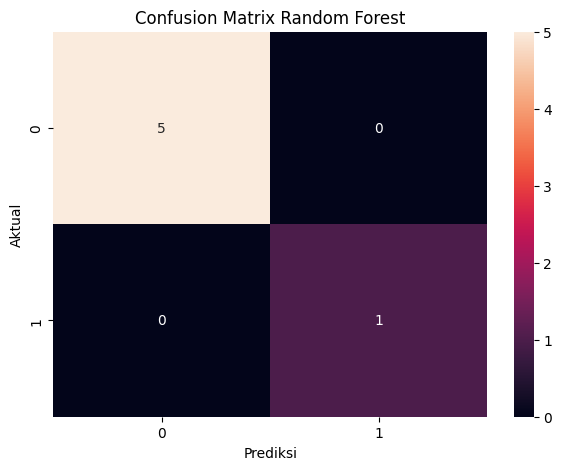

In [16]:
# Menampilkan confusion matrix dalam bentuk grafik

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

In [17]:
# Menampilkan classification report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [18]:
# Melihat fitur mana yang paling berpengaruh pada model Random Forest

feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Nilai Importance': model_rf.feature_importances_
})

# Mengurutkan fitur dari yang paling berpengaruh
feature_importance = feature_importance.sort_values(
    by='Nilai Importance',
    ascending=False
)

feature_importance

,Fitur,Nilai Importance
4,monthly_charge,0.341913
5,tenure,0.296219
2,internet_service,0.264177
3,online_security,0.070342
1,partner,0.020229
0,gender,0.007121


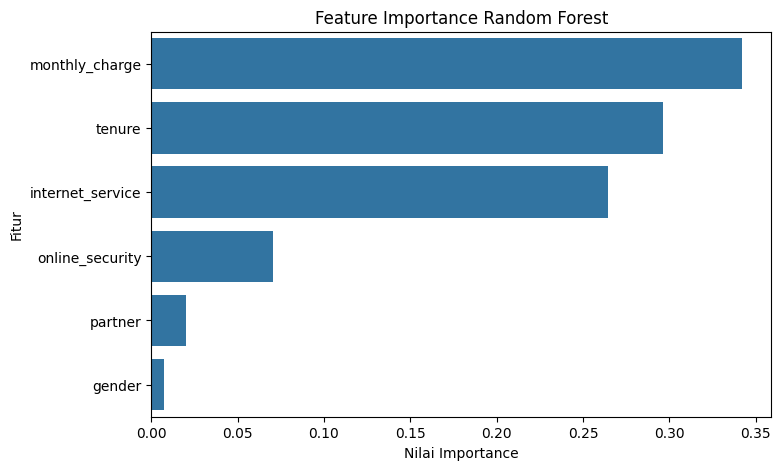

In [19]:
# Membuat grafik feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Nilai Importance',
    y='Fitur',
    data=feature_importance
)

plt.title("Feature Importance Random Forest")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")

plt.show()

In [20]:
# Membuat data baru yang akan diprediksi oleh model

data_baru = pd.DataFrame({
    'gender': [1, 0, 1, 0, 1],
    'partner': [1, 0, 1, 0, 0],
    'internet_service': [3, 2, 1, 2, 3],
    'online_security': [0, 1, 0, 1, 0],
    'monthly_charge': [95, 55, 25, 60, 100],
    'tenure': [4, 30, 40, 25, 3]
})

# Menampilkan data baru
data_baru

,gender,partner,internet_service,online_security,monthly_charge,tenure
0,1,1,3,0,95,4
1,0,0,2,1,55,30
2,1,1,1,0,25,40
3,0,0,2,1,60,25
4,1,0,3,0,100,3


In [21]:
# Melakukan prediksi pada data baru

prediksi_baru = model_rf.predict(data_baru)

# Menambahkan hasil prediksi ke data baru
data_baru['churn'] = prediksi_baru

# Menampilkan data baru beserta hasil prediksi
data_baru

,gender,partner,internet_service,online_security,monthly_charge,tenure,churn
0,1,1,3,0,95,4,1
1,0,0,2,1,55,30,0
2,1,1,1,0,25,40,0
3,0,0,2,1,60,25,0
4,1,0,3,0,100,3,1


In [22]:
# Mengubah hasil prediksi angka menjadi teks

label_churn = {
    1: 'Churn',
    0: 'Tidak Churn'
}

data_baru['churn'] = data_baru['churn'].map(label_churn)

# Menampilkan hasil akhir
data_baru

,gender,partner,internet_service,online_security,monthly_charge,tenure,churn
0,1,1,3,0,95,4,Churn
1,0,0,2,1,55,30,Tidak Churn
2,1,1,1,0,25,40,Tidak Churn
3,0,0,2,1,60,25,Tidak Churn
4,1,0,3,0,100,3,Churn


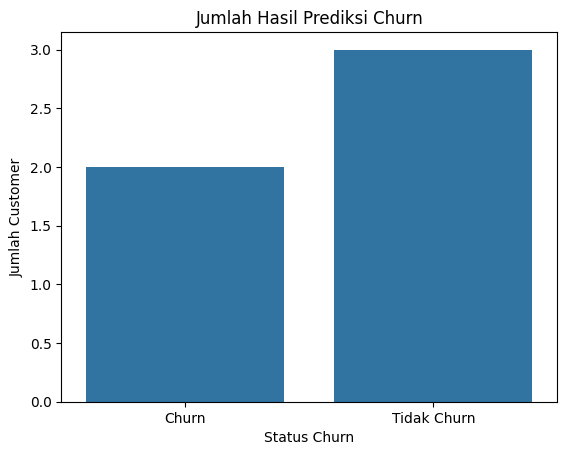

In [23]:
# Membuat grafik batang hasil prediksi churn

sns.countplot(
    x='churn',
    data=data_baru
)

plt.title("Jumlah Hasil Prediksi Churn")
plt.xlabel("Status Churn")
plt.ylabel("Jumlah Customer")

plt.show()

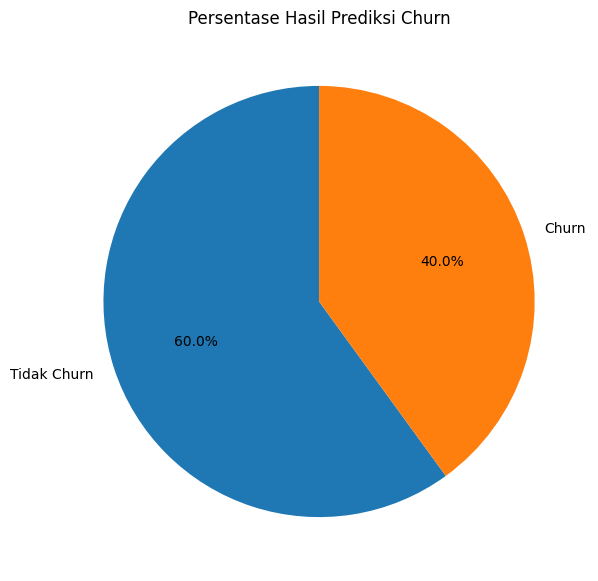

In [24]:
# Menghitung jumlah masing-masing hasil prediksi churn

jumlah_churn = data_baru['churn'].value_counts()

# Membuat pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    jumlah_churn.values,
    labels=jumlah_churn.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Persentase Hasil Prediksi Churn")

plt.show()

In [25]:
# Menyimpan hasil prediksi ke file CSV

data_baru.to_csv("outputRandomForest.csv", index=False)